In [1]:
# Data Science Toolkit
from ds_toolkit.data import Dataset, DatasetConfig

# External libraries
import pandas as pd
from pathlib import Path

In [2]:
data = pd.read_csv(Path().cwd() / "sample_scoring_dataset.csv")
print(data.head(3))

   salary  default  id        date  age  loan_amount  credit_load  \
0     152        0   1  2025-01-01   44       235732         3.47   
1     485        0   2  2025-01-02   25       181836         0.39   
2     398        1   3  2025-01-03   54       215615         4.58   

   active_loans  nbki_score  requests_30d  mfo_loans_ever  days_from_last_loan  
0             4         807            11              13                  325  
1             2         668             4               1                 1433  
2             3         708            13              16                 1141  


In [3]:
# Convert field `date` to datetime format
data["date"] = pd.to_datetime(data["date"])

In [4]:
# Create Dataset Config
dataset_confid = DatasetConfig(
    id_column="id",
    date_column="date",
    target_columns=["default"],
)

In [5]:
# Create Data Science Toolkit
dataset = Dataset(data, dataset_confid)

In [6]:
from ds_toolkit.data import split_train_test_oot

train, test, oot = split_train_test_oot(dataset, test_size=0.4, oot_size=0.15)

In [7]:
print("Size:", len(dataset.sample))
print(dataset.sample.head(2))

Size: 100
   salary  default  id       date  age  loan_amount  credit_load  \
0     152        0   1 2025-01-01   44       235732         3.47   
1     485        0   2 2025-01-02   25       181836         0.39   

   active_loans  nbki_score  requests_30d  mfo_loans_ever  days_from_last_loan  
0             4         807            11              13                  325  
1             2         668             4               1                 1433  


In [8]:
full_sample = pd.concat([train.sample, test.sample, oot.sample], ignore_index=True)
print("Size:", len(full_sample))
full_sample["sample_type"].value_counts(normalize=True)

Size: 100


sample_type
train    0.51
test     0.34
oot      0.15
Name: proportion, dtype: float64

In [9]:
train_test_sample = pd.concat([train.sample, test.sample], ignore_index=True)
print("Size:", len(train_test_sample))
train_test_sample["sample_type"].value_counts(normalize=True)

Size: 85


sample_type
train    0.6
test     0.4
Name: proportion, dtype: float64

## VIF (Variance Inflation Factor)

<Axes: title={'center': 'Variance Inflation Factor'}, xlabel='VIF', ylabel='Feature'>

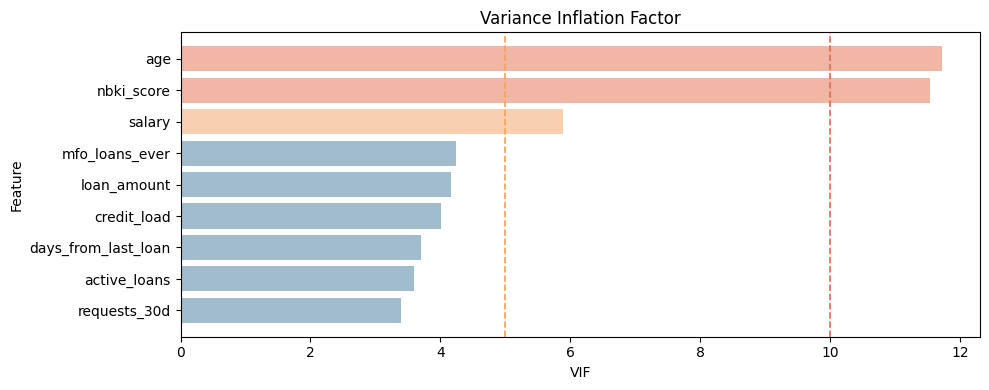

In [11]:
from ds_toolkit.feature_selection import VarianceInflationFactor

VarianceInflationFactor.visualization(dataset)

In [12]:
print(VarianceInflationFactor.report(dataset))

               feature        vif   status
0                  age  11.717312     high
1           nbki_score  11.529629     high
2               salary   5.884819  warning
3       mfo_loans_ever   4.241479       ok
4          loan_amount   4.165152       ok
5          credit_load   4.013163       ok
6  days_from_last_loan   3.693900       ok
7         active_loans   3.596693       ok
8         requests_30d   3.392352       ok
